# 04b — Training Loop (smoke test)

**Proyecto:** D10Sformer — MIA305 (UdeSA, 2026)  
**Fase:** 4b — Training loop con AMP + cosine schedule + logging local

## Objetivo

Validar que el training loop está bien armado **antes** del run de pre-training real. Específicamente:

1. Cargar los pickles del corpus generados en Fase 4a.
2. Instanciar el modelo con `max_seq_length=80` (justificación: p99 de Fase 4a fue 64) → batch grande, throughput alto.
3. Correr **200 pasos** de smoke test con MLM puro sobre un subset del pretrain.
4. Verificar que la loss **baja** (de ~ln(4521) ≈ 8.4 hacia ~5), la perplexity también, y la MLM accuracy sube.
5. Verificar que el checkpoint guardado se puede recargar exactamente.
6. Correr la suite de tests de training (5 + 5 + 5 = 15 tests nuevos).

Después del smoke test, si todo se ve bien, en Fase 4c vamos a correr el **pre-training real**: ~1 época sobre los 11.852 docs (≈ 370 pasos a batch=32, o ~93 a batch=128).

---
## 1. Setup

In [4]:
print('# %load_ext autoreload')
print('# %autoreload 2')
# These lines are causing an error in Python 3.12 due to the removal of the 'imp' module.
# If you need autoreload functionality, you might need to update your IPython environment or find an alternative.


# %load_ext autoreload
# %autoreload 2


In [5]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/d10sformer'
except ImportError:
    import os
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f'PROJECT_ROOT = {PROJECT_ROOT}')

Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/d10sformer


In [6]:
import sys
import json
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

ROOT = Path(PROJECT_ROOT)
sys.path.insert(0, str(ROOT / 'src'))

DATA_PROCESSED = ROOT / 'data' / 'processed'
CORPUS_DIR = DATA_PROCESSED / 'corpus'
VOCAB_PATH = DATA_PROCESSED / 'vocab.json'
CKPT_DIR = ROOT / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

assert (CORPUS_DIR / 'pretrain.pkl').exists(), 'Faltan los pickles de Fase 4a'
print(f'✓ Corpus encontrado en {CORPUS_DIR}')

✓ Corpus encontrado en /content/drive/MyDrive/d10sformer/data/processed/corpus


In [7]:
from data.vocabulary import FootballVocab
from data.tokenizer import MatchTokenizer
from data.dataset import MatchDataset
from data.collator import MLMCollator
from models.d10sformer import D10Sformer, D10SformerConfig
from training.trainer import Trainer, TrainerConfig, LossSpec

print('torch:', torch.__version__)
print('CUDA disponible:', torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

torch: 2.9.0+cpu
CUDA disponible: False
device: cpu


---
## 2. Cargar vocab + corpus

In [8]:
vocab = FootballVocab.load(VOCAB_PATH)

# max_seq_length=80: p99 de Fase 4a fue 64 → margen de 16 tokens.
tokenizer = MatchTokenizer(vocab, max_seq_length=80)

with open(CORPUS_DIR / 'pretrain.pkl', 'rb') as f:
    pretrain_docs = pickle.load(f)
with open(CORPUS_DIR / 'val.pkl', 'rb') as f:
    val_docs = pickle.load(f)

print(f'pretrain docs: {len(pretrain_docs):,}')
print(f'val docs:      {len(val_docs):,}')

pretrain docs: 11,852
val docs:      1,232


---
## 3. Dataset + DataLoader

Para el smoke usamos batch_size=64 y un subset chico (1000 docs). Para Fase 4c vamos a usar el corpus completo.

In [9]:
import random
random.seed(0)
smoke_docs = random.sample(pretrain_docs, 1000)

ds_train = MatchDataset(smoke_docs, tokenizer)
ds_val   = MatchDataset(val_docs[:200], tokenizer)

collator = MLMCollator(vocab, mlm_probability=0.15, seed=42)

BATCH_SIZE = 64
train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collator, num_workers=0)
val_loader   = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collator, num_workers=0)

print(f'Train batches: {len(train_loader)}  (batch_size={BATCH_SIZE})')
print(f'Val batches:   {len(val_loader)}')

# Sanity: peek at one batch shape
sample_batch = next(iter(train_loader))
print(f'\nBatch token_ids shape: {tuple(sample_batch.token_ids.shape)}')
print(f'Batch attention_mask sum/total: {sample_batch.attention_mask.sum().item()} / {sample_batch.attention_mask.numel()}')

Train batches: 16  (batch_size=64)
Val batches:   4

Batch token_ids shape: (64, 63)
Batch attention_mask sum/total: 2013 / 4032


---
## 4. Instanciar modelo + Trainer

In [10]:
model_config = D10SformerConfig(
    vocab_size=len(vocab),
    d_model=256, num_layers=6, num_heads=8, d_ff=1024,
    max_seq_length=80,   # ← actualizado para coincidir con el tokenizer
    num_segments=8,
    dropout=0.1, attention_dropout=0.1,
    pad_token_id=vocab.encode('[PAD]'),
    tie_mlm_weights=True,
)
model = D10Sformer(model_config)
print(f'Modelo: {model.num_parameters():,} parámetros')

trainer_config = TrainerConfig(
    lr=5e-4, weight_decay=0.01,
    grad_clip_norm=1.0, warmup_ratio=0.1,
    max_steps=200,            # ← smoke test
    mixed_precision=True,     # AMP en GPU
    log_every=10,
    eval_every=100,           # 1 eval a mitad y otra al final
    save_every=0,             # no guardamos intermedios en smoke
    save_best=True,
    output_dir=str(CKPT_DIR),
    run_name='smoke_test_pretrain',
    seed=42,
)
loss_spec = LossSpec(use_mlm=True, use_result=False, use_score=False)

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    config=trainer_config,
    loss_spec=loss_spec,
)
print(f'Device: {trainer.device}')
print(f'AMP enabled: {trainer.use_amp}')
print(f'Output dir: {trainer.output_dir}')

Modelo: 6,131,920 parámetros
Device: cpu
AMP enabled: False
Output dir: /content/drive/MyDrive/d10sformer/checkpoints/smoke_test_pretrain


---
## 5. Smoke run (200 pasos)

**Loss inicial esperada:** ~ln(vocab_size) = ln(4521) ≈ 8.42 — el modelo aleatorio está en máxima entropía sobre el vocabulario.

**Después de 200 pasos esperamos:** loss en ~5-6, perplexity ~150-400, MLM accuracy ~15-25%.

Si la loss no baja de 8.0 en 200 pasos, hay un bug (sospechar: lr, gradient flow, masking).

In [12]:
import time
t0 = time.time()
trainer.output_dir.mkdir(parents=True, exist_ok=True) # Ensure the output directory exists
trainer.train()
elapsed = time.time() - t0
print(f'\n✓ Smoke test completado en {elapsed:.1f}s ({200/elapsed:.1f} step/s)')

[step     30/200] lr=4.96e-04  loss=7.1226  ppl=1239.65  mlm_acc=0.1239  (1.8 step/s)
[step     40/200] lr=4.85e-04  loss=6.6938  ppl=807.39  mlm_acc=0.1263  (1.2 step/s)
[step     50/200] lr=4.67e-04  loss=6.1094  ppl=450.06  mlm_acc=0.1514  (1.0 step/s)
[step     60/200] lr=4.42e-04  loss=5.8445  ppl=345.33  mlm_acc=0.1756  (0.9 step/s)
[step     70/200] lr=4.11e-04  loss=5.6442  ppl=282.65  mlm_acc=0.1606  (0.9 step/s)
[step     80/200] lr=3.75e-04  loss=5.3110  ppl=202.55  mlm_acc=0.1703  (0.8 step/s)
[step     90/200] lr=3.36e-04  loss=5.5678  ppl=261.86  mlm_acc=0.1575  (0.8 step/s)
[step    100/200] lr=2.93e-04  loss=5.3055  ppl=201.43  mlm_acc=0.1755  (0.8 step/s)
[eval @ step    100] val_loss=3.2458  val_ppl=25.68  val_acc=0.2288
[step    110/200] lr=2.50e-04  loss=5.3036  ppl=201.05  mlm_acc=0.1617  (0.7 step/s)
[step    120/200] lr=2.07e-04  loss=5.1446  ppl=171.50  mlm_acc=0.1771  (0.7 step/s)
[step    130/200] lr=1.64e-04  loss=5.3322  ppl=206.90  mlm_acc=0.1615  (0.7 step

---
## 6. Curvas de loss / accuracy / lr

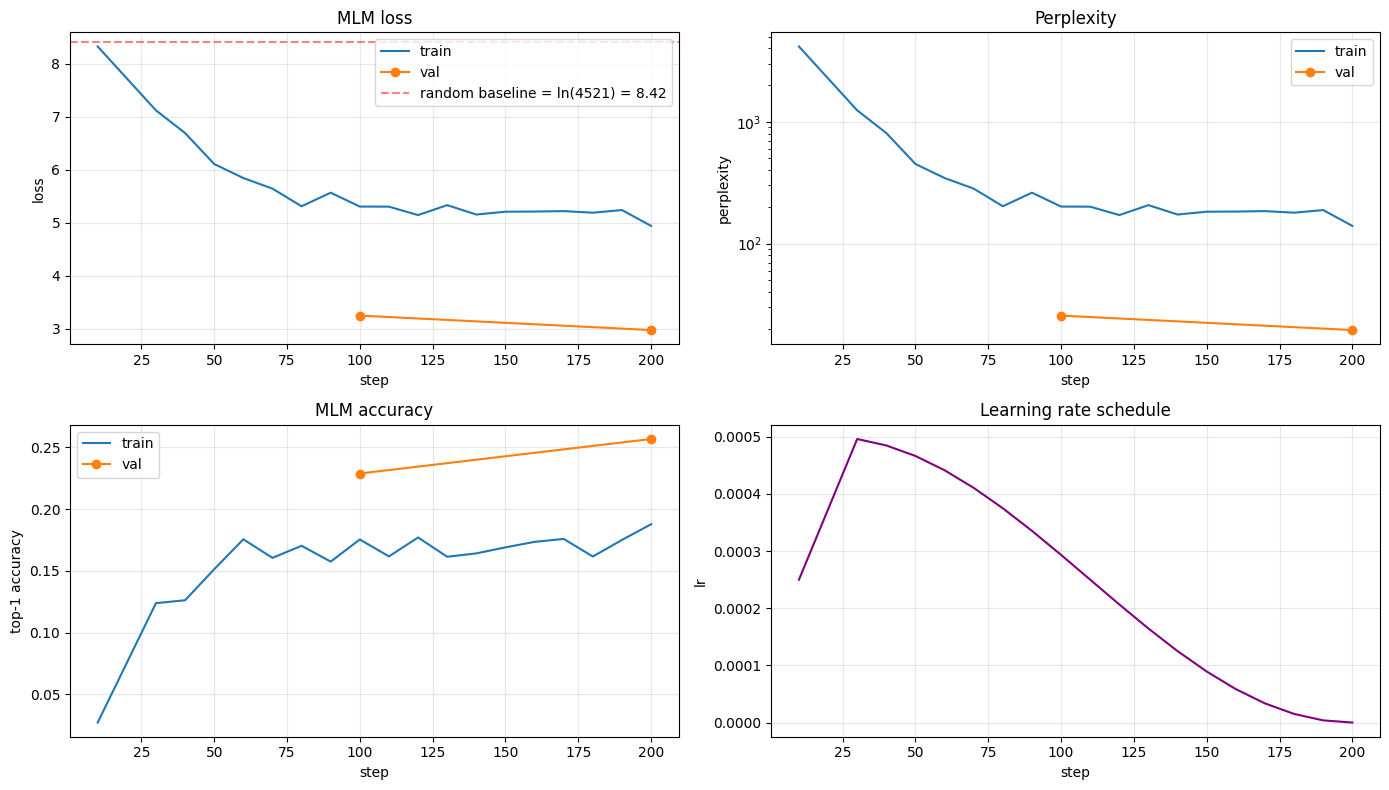

In [13]:
# Leer el log JSONL
log_path = trainer.log_path
rows = [json.loads(line) for line in log_path.read_text().splitlines() if line.strip()]
train_rows = [r for r in rows if 'phase' not in r]
eval_rows  = [r for r in rows if r.get('phase') == 'eval']

steps_train = [r['step'] for r in train_rows]
loss_train  = [r['loss'] for r in train_rows]
ppl_train   = [r['mlm_perplexity'] for r in train_rows]
acc_train   = [r['mlm_acc'] for r in train_rows]
lr_train    = [r['lr'] for r in train_rows]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(steps_train, loss_train, label='train')
if eval_rows:
    axes[0, 0].plot([r['step'] for r in eval_rows], [r['val_loss'] for r in eval_rows], 'o-', label='val')
axes[0, 0].axhline(np.log(len(vocab)), linestyle='--', color='red', alpha=0.5,
                   label=f'random baseline = ln({len(vocab)}) = {np.log(len(vocab)):.2f}')
axes[0, 0].set_xlabel('step'); axes[0, 0].set_ylabel('loss'); axes[0, 0].set_title('MLM loss')
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(steps_train, ppl_train, label='train')
if eval_rows:
    axes[0, 1].plot([r['step'] for r in eval_rows], [r['val_mlm_perplexity'] for r in eval_rows], 'o-', label='val')
axes[0, 1].set_xlabel('step'); axes[0, 1].set_ylabel('perplexity')
axes[0, 1].set_title('Perplexity'); axes[0, 1].set_yscale('log')
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(steps_train, acc_train, label='train')
if eval_rows:
    axes[1, 0].plot([r['step'] for r in eval_rows], [r['val_mlm_acc'] for r in eval_rows], 'o-', label='val')
axes[1, 0].set_xlabel('step'); axes[1, 0].set_ylabel('top-1 accuracy')
axes[1, 0].set_title('MLM accuracy'); axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(steps_train, lr_train, color='purple')
axes[1, 1].set_xlabel('step'); axes[1, 1].set_ylabel('lr')
axes[1, 1].set_title('Learning rate schedule')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Diagnóstico cuantitativo: ¿bajó la loss?
print('=== Diagnóstico de aprendizaje ===')
print(f'Random baseline (ln(V)):      {np.log(len(vocab)):.4f}')
print(f'Loss inicial (paso {steps_train[0]:>3}):     {loss_train[0]:.4f}  →  ppl {ppl_train[0]:8.2f}  acc {acc_train[0]:.4f}')
print(f'Loss final   (paso {steps_train[-1]:>3}):     {loss_train[-1]:.4f}  →  ppl {ppl_train[-1]:8.2f}  acc {acc_train[-1]:.4f}')
print(f'Reducción de loss:             {100 * (loss_train[0] - loss_train[-1]) / loss_train[0]:.1f}%')
if eval_rows:
    print(f'\nVal final: loss={eval_rows[-1]["val_loss"]:.4f}  ppl={eval_rows[-1]["val_mlm_perplexity"]:.2f}  acc={eval_rows[-1]["val_mlm_acc"]:.4f}')

ok_signal = loss_train[-1] < loss_train[0] - 0.5
print(f'\n{"✓" if ok_signal else "⚠"} Señal de aprendizaje: {"OK" if ok_signal else "WEAK"} (esperábamos al menos −0.5 de loss)')

=== Diagnóstico de aprendizaje ===
Random baseline (ln(V)):      8.4165
Loss inicial (paso  10):     8.3287  →  ppl  4141.03  acc 0.0273
Loss final   (paso 200):     4.9401  →  ppl   139.78  acc 0.1878
Reducción de loss:             40.7%

Val final: loss=2.9729  ppl=19.55  acc=0.2568

✓ Señal de aprendizaje: OK (esperábamos al menos −0.5 de loss)


---
## 7. Checkpoint roundtrip

Verificamos que podemos guardar y recargar el modelo exactamente.

In [15]:
from copy import deepcopy
ckpt_path = trainer.output_dir / 'final.pt'
print(f'Checkpoint guardado: {ckpt_path}  ({ckpt_path.stat().st_size / 1024 / 1024:.1f} MB)')

# Construir un trainer nuevo + recargar
model2 = D10Sformer(model_config)
trainer2 = Trainer(
    model=model2, train_loader=train_loader, val_loader=val_loader,
    config=trainer_config, loss_spec=loss_spec,
)
trainer2.load_checkpoint(ckpt_path)

# Comparar todos los parámetros
match = True
for (n1, p1), (n2, p2) in zip(trainer.model.named_parameters(), trainer2.model.named_parameters()):
    if not torch.allclose(p1, p2, atol=1e-6):
        match = False
        print(f'✗ Mismatch en {n1}')
        break
print(f'{"✓" if match else "✗"} Roundtrip de parámetros: {"idénticos" if match else "DIFERENTES"}')
print(f'  step restaurado: {trainer2.step}  (debe ser {trainer.step})')
print(f'  best_val_loss:   {trainer2.best_val_loss}')

Checkpoint guardado: /content/drive/MyDrive/d10sformer/checkpoints/smoke_test_pretrain/final.pt  (69.2 MB)
✓ Roundtrip de parámetros: idénticos
  step restaurado: 200  (debe ser 200)
  best_val_loss:   2.972882926464081


---
## 8. Suite de tests

In [16]:
import subprocess
result = subprocess.run(
    ['python', '-m', 'pytest',
     str(ROOT / 'tests' / 'test_scheduler.py'),
     str(ROOT / 'tests' / 'test_training_metrics.py'),
     str(ROOT / 'tests' / 'test_trainer.py'),
     '-v', '--tb=short'],
    capture_output=True, text=True,
)
print(result.stdout[-4000:])
if result.stderr:
    print('STDERR:', result.stderr[-800:])
print(f'Exit code: {result.returncode}')

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: anyio-4.13.0
collecting ... collected 15 items

drive/MyDrive/d10sformer/tests/test_scheduler.py::test_warmup_starts_near_zero PASSED [  6%]
drive/MyDrive/d10sformer/tests/test_scheduler.py::test_warmup_reaches_base_lr_at_warmup_steps PASSED [ 13%]
drive/MyDrive/d10sformer/tests/test_scheduler.py::test_cosine_decays_to_zero_by_end PASSED [ 20%]
drive/MyDrive/d10sformer/tests/test_scheduler.py::test_min_lr_ratio_respected PASSED [ 26%]
drive/MyDrive/d10sformer/tests/test_scheduler.py::test_invalid_args_raise PASSED [ 33%]
drive/MyDrive/d10sformer/tests/test_training_metrics.py::test_mlm_loss_ignores_minus_100 PASSED [ 40%]
drive/MyDrive/d10sformer/tests/test_training_metrics.py::test_mlm_accuracy_perfect PASSED [ 46%]
drive/MyDrive/d10sformer/tests/test_training_metrics.py::tes

---
## 9. Conclusiones de Fase 4b (llenar al final)

- [ ] Loss inicial (paso 10): _____
- [ ] Loss final (paso 200): _____
- [ ] Reducción de loss: _____% (esperado ≥ 30%)
- [ ] Perplexity inicial / final: _____ / _____
- [ ] MLM accuracy final: _____ (esperado > 0.10)
- [ ] Val loss final: _____
- [ ] Steps por segundo: _____ (T4 esperado: 5-15 step/s con batch 64)
- [ ] Tests pasados / total: _____ / 15
- [ ] Checkpoint roundtrip OK: _____

**Si todo verde → Fase 4c (training real):** 3-5 épocas sobre el corpus completo, lo cual son ~550 a ~900 pasos a batch=64. Estimación T4: 60-90 minutos.